Title : Pokemon TCG : EDA & Deck Engine
url : https://www.kaggle.com/code/nursrijan/pokemon-tcg-eda-deck-engine

In [65]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
    
except ImportError:
    display=print
    
sns.set_theme(style='whitegrid', context='notebook', palette='crest')
plt.rcParams.update({
    'font.size' :11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize':10,
    'ytick.labelsize':10,
    'figure.titlesize':16
})

In [67]:
data_dir='C:\Git_for_study\DE\Practice\Kaggle\Data\Pokemon TCG\EN Card Data.csv'
try:
    df=pd.read_csv(data_dir)
    print(f'Dataset successfully loaded. Raw shape:{df.shape}')
except Exception as e:
    print(f'Failed to load dataset :{e}')
    df=pd.DataFrame()
    
df.columns=df.columns.str.strip()
for col in df.select_dtypes(include=['object']).columns:
    df[col]=df[col].astype(str).str.strip()
    df[col]=df[col].replace({'nan':np.nan, 'None':np.nan, 'n/a':np.nan})

Dataset successfully loaded. Raw shape:(2022, 17)


In [94]:
def parse_damage(dmg_str):
    if pd.isna(dmg_str):
        return np.nan, 'None'
    dmg_str=str(dmg_str).strip()
    if not dmg_str or dmg_str=='No cost':
        return np.nan, 'None'
    
    if 'x' in dmg_str:
        val=re.findall(r'\d+', dmg_str)
        if val:
            return float(val[0]), 'Multiplier'
        
    elif '-' in dmg_str:
        val=re.findall(r'\d+', dmg_str)
        if val:
            return float(val[0]), 'Conditional'
        
    else:
        val=re.findall(r'\d+', dmg_str)
        if val:
            return float(val[0]), 'Static'
        
    return np.nan, 'None'

def parse_cost_count(cost_str):
    if pd.isna(cost_str) or cost_str=='No cost':
        return 0
    cost_str=str(cost_str).strip()
    colorless_count=cost_str.count('●')
    colored_count=cost_str.count('{')
    return colorless_count+colored_count

df['HP']=pd.to_numeric(df['HP'], errors='coerce')
df['Retreat_Cleaned']=df['Retreat'].fillna(0.0)
df['Type']=df['Type'].replace('竜', '{Dragon}')

In [73]:
df_unique=df.drop_duplicates(subset=['Card ID']).copy()

print(f'Total rows in raw CSV:{len(df)}')
print(f'Total unique cards in set :{len(df_unique)}')
print(f'Double-counted rows avoided:{len(df)-len(df_unique)}')

Total rows in raw CSV:2022
Total unique cards in set :1267
Double-counted rows avoided:755


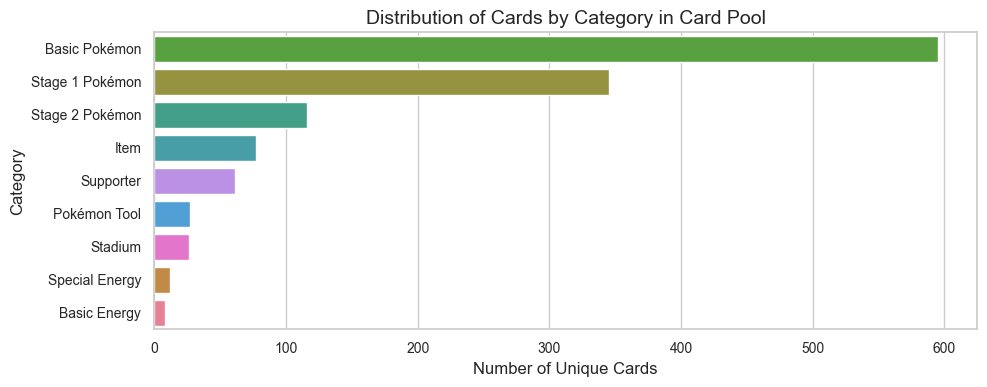

In [77]:
plt.figure(figsize=(10, 4))
sns.countplot(
    data=df_unique, 
    y='Stage (Pokémon)/Type (Energy and Trainer)', 
    order=df_unique['Stage (Pokémon)/Type (Energy and Trainer)'].value_counts().index,
    hue='Stage (Pokémon)/Type (Energy and Trainer)',
    legend=False
)
plt.title('Distribution of Cards by Category in Card Pool')
plt.xlabel('Number of Unique Cards')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [81]:
rule_counts=df_unique['Rule'].fillna('Normal').value_counts()
print('Card Rule Types Distribution:')
for rule, count in rule_counts.items():
    print(f"- {rule:18s}: {count:4d} cards ({count/len(df_unique)*100:.1f}%)")

Card Rule Types Distribution:
- Normal            : 1087 cards (85.8%)
- Pokémon ex        :  121 cards (9.6%)
- Mega Pokémon ex   :   30 cards (2.4%)
- ACE SPEC          :   29 cards (2.3%)


In [82]:
pok_unique = df_unique[df_unique['Stage (Pokémon)/Type (Energy and Trainer)'].str.contains('Pokémon', na=False) & 
                       ~df_unique['Stage (Pokémon)/Type (Energy and Trainer)'].str.contains('Tool', na=False)].copy()
print(f"Total Unique Pokémon Characters: {len(pok_unique)}")

Total Unique Pokémon Characters: 1056


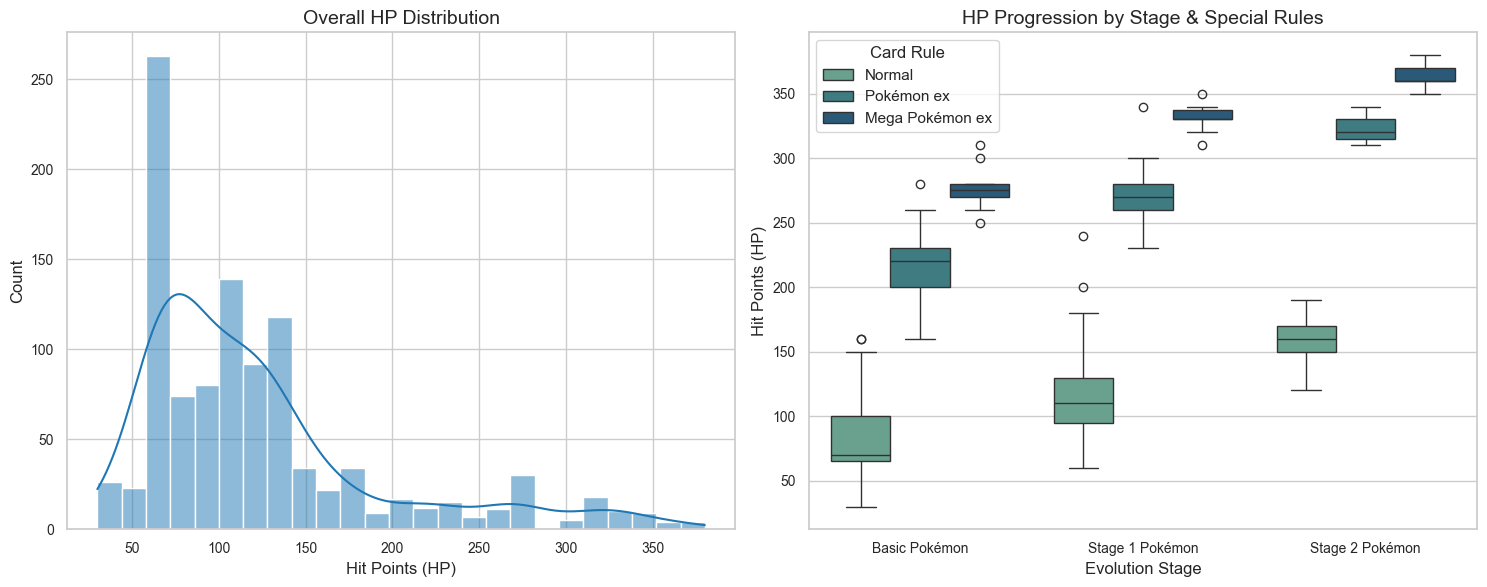

In [83]:
fig, axes= plt.subplots(1,2, figsize=(15,6))

sns.histplot(data=pok_unique, x='HP', kde=True, bins=25, ax=axes[0], color='#1f77b4')
axes[0].set_title('Overall HP Distribution')
axes[0].set_xlabel('Hit Points (HP)')
axes[0].set_ylabel('Count')

stage_order = ['Basic Pokémon', 'Stage 1 Pokémon', 'Stage 2 Pokémon']
rule_order = ['Normal', 'Pokémon ex', 'Mega Pokémon ex']
pok_stages = pok_unique[pok_unique['Stage (Pokémon)/Type (Energy and Trainer)'].isin(stage_order)].copy()
pok_stages['Rule_Clean'] = pok_stages['Rule'].fillna('Normal')
sns.boxplot(
    data=pok_stages,
    x='Stage (Pokémon)/Type (Energy and Trainer)', 
    y='HP', 
    hue='Rule_Clean',
    hue_order=rule_order,
    order=stage_order,
    palette='crest',
    ax=axes[1]
)
axes[1].set_title('HP Progression by Stage & Special Rules')
axes[1].set_xlabel('Evolution Stage')
axes[1].set_ylabel('Hit Points (HP)')
axes[1].legend(title='Card Rule')

plt.tight_layout()
plt.show()

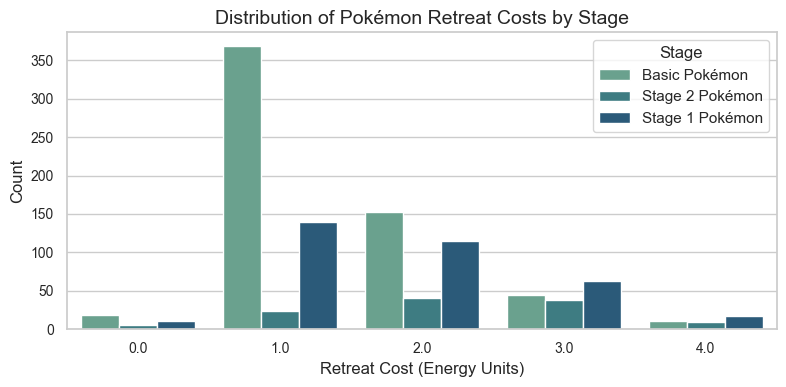

In [84]:
plt.figure(figsize=(8,4))
sns.countplot(data=pok_stages, x='Retreat_Cleaned', hue='Stage (Pokémon)/Type (Energy and Trainer)', palette='crest')
plt.title('Distribution of Pokémon Retreat Costs by Stage')
plt.xlabel('Retreat Cost (Energy Units)')
plt.ylabel('Count')
plt.legend(title='Stage')
plt.tight_layout()
plt.show()

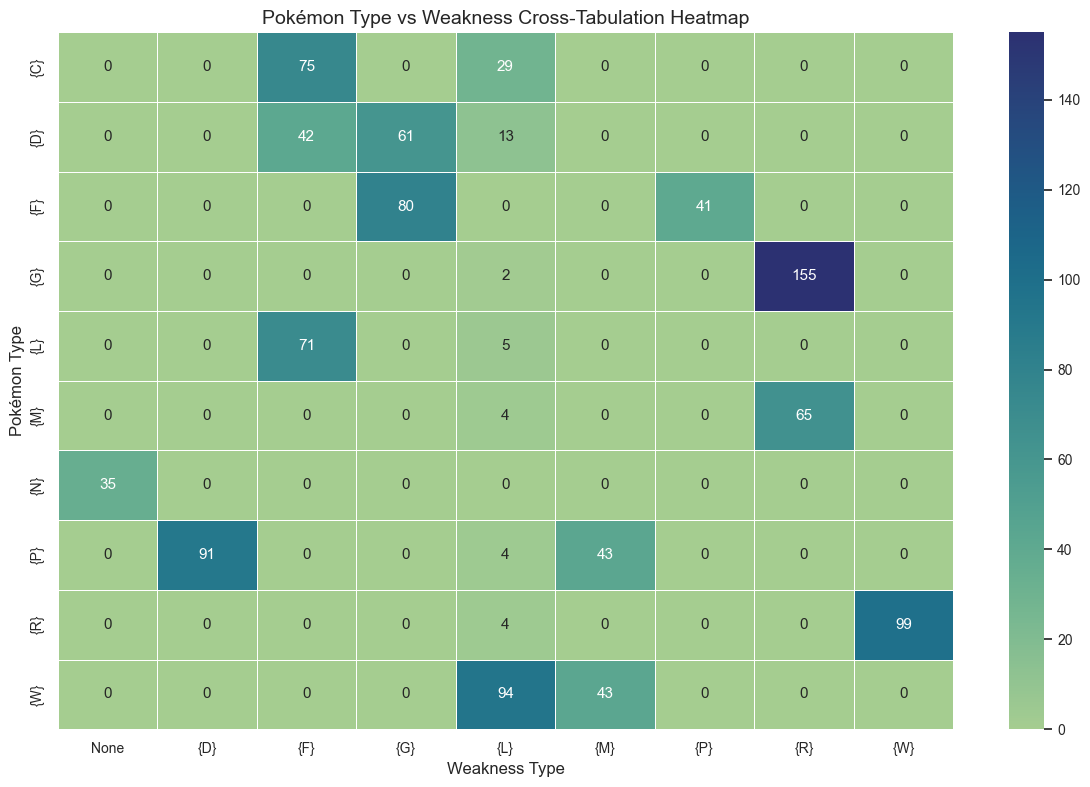

In [85]:
pok_unique['Weakness_Clean'] = pok_unique['Weakness'].fillna('None')
crosstab = pd.crosstab(pok_unique['Type'], pok_unique['Weakness_Clean'])

plt.figure(figsize=(12, 8))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='crest', cbar=True, linewidths=0.5)
plt.title('Pokémon Type vs Weakness Cross-Tabulation Heatmap')
plt.xlabel('Weakness Type')
plt.ylabel('Pokémon Type')
plt.tight_layout()
plt.show()

In [98]:
attacks=df[df['Move Name'].notna() & df['Cost'].notna()].copy()
attacks['Energy_Cost']=attacks['Cost'].apply(parse_cost_count)

parsed_dmg=attacks['Damage'].apply(lambda x :parse_damage(x))
attacks['Base_Damage']=[x[0] for x in parsed_dmg]
attacks['Damage_Type']=[x[1] for x in parsed_dmg]

attacks_dpe=attacks[(attacks['Energy_Cost'] >0 ) & (attacks['Base_Damage'].notna())].copy()
attacks_dpe['DPE']=attacks_dpe['Base_Damage']/attacks_dpe['Energy_Cost']


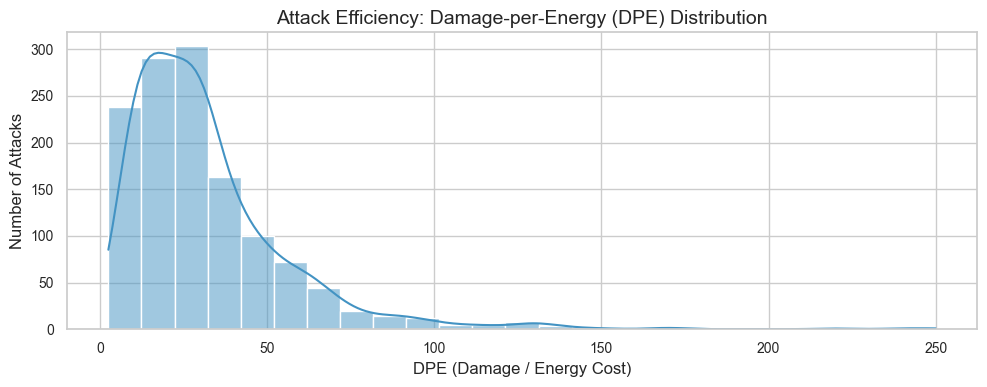

In [99]:
plt.figure(figsize=(10, 4))
sns.histplot(data=attacks_dpe, x='DPE', kde=True, bins=25, color='#4393c3')
plt.title('Attack Efficiency: Damage-per-Energy (DPE) Distribution')
plt.xlabel('DPE (Damage / Energy Cost)')
plt.ylabel('Number of Attacks')
plt.tight_layout()
plt.show()


In [ ]:
class TCGDeckBuilder:
    def __init__(self,df):
        self.df=df.copy()
        
    def trace_evolution(self, pokemon_name):
        path=[pokemon_name]
        current=pokemon_name
        
        while True:
            rows=self.df[self.df['Card Name']==current]
            if rows.empty:
                break
            prev=rows.iloc[0]['Previous stage']
            if pd.isna(prev) or prev == current or prev =='None':
                break
            prev=str(prev).strip()
            path.append(prev)
            current=prev
        return path
    
    def build_deck(self, main_attacker, archetype_name):
        deck={}
        evo_line=self.trace_evolution(main_attacker)
        
        for idx, card in enumerate(reversed(evo_line)):
            if idx==0:
                deck[card]=4
                
            elif idx==1:
                deck[card]=3
            else:
                deck[card]=3
                
                